[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/08_stochastic_optimization_for_ml/first_principles.ipynb)

# Module 08 — Stochastic Optimization for Machine Learning

## 1. Why This Module Exists

Supervised learning minimizes an **empirical risk** that is an average over $N$ examples,

$$
f(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N f_i(\mathbf{x}), \qquad f_i(\mathbf{x}) = \ell\left(\text{model}_{\mathbf{x}}(\mathbf{a}_i),\, b_i\right)
$$

standing in for the **expected risk** $F(\mathbf{x}) = \mathbb{E}_{(\mathbf{a},b)\sim\mathcal{D}}\left[\ell(\cdot)\right]$
over the unknown data distribution. Exact gradient descent needs

$$
\nabla f(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N \nabla f_i(\mathbf{x})
$$

which costs one full pass over the dataset *per step*.

With $N = 10^9$ that is absurd. The gradient is an average, and averages are exactly the quantity that
random sampling estimates well. A single example already points roughly downhill; a batch of $32$ points
downhill with quantifiable accuracy.

The bargain is therefore explicit: **trade gradient accuracy for the number of updates**. In the time one
exact gradient step takes, stochastic gradient descent takes $N/B$ noisy steps.

Everything in this module answers one question: *when is that trade a good one, and under what step-size
discipline does the noise fail to destroy convergence?* The answers — the $1/B$ variance law, the noise
ball, the Robbins-Monro conditions, variance reduction and per-coordinate preconditioning — are the
entire content of a modern training recipe.

## 2. Intuition

### 2.1 Noise Is a Tax, Not a Wall

Write the stochastic gradient as its mean plus a fluctuation:

$$
\mathbf{g}_k = \nabla f(\mathbf{x}_k) + \boldsymbol{\epsilon}_k, \qquad \mathbb{E}\left[\boldsymbol{\epsilon}_k \mid \mathbf{x}_k\right] = \mathbf{0}, \qquad \mathbb{E}\left[\lVert \boldsymbol{\epsilon}_k\rVert^2 \mid \mathbf{x}_k\right] \le \frac{\sigma^2}{B}
$$

Two facts organize everything that follows.

**Unbiasedness** means the *drift* of the iterate is still the true descent direction, so in expectation
the algorithm makes deterministic progress.

**Variance** means each step also injects energy. Feeding $\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\mathbf{g}_k$
into the descent lemma produces the master inequality of Theorem 4.2,

$$
\mathbb{E}\left[f(\mathbf{x}_{k+1})\right] \le f(\mathbf{x}_k) - \alpha\left(1 - \frac{L\alpha}{2}\right)\lVert \nabla f(\mathbf{x}_k)\rVert^2 + \frac{L\alpha^2\sigma^2}{2B}
$$

The first correction is the familiar deterministic descent term; the second is the **noise tax**.

Note the asymmetry in $\alpha$: progress is $O(\alpha)$ while the tax is $O(\alpha^2)$. Small steps
therefore make the tax negligible — but also make progress slow. That single trade-off dictates every
step-size schedule in machine learning.

### 2.2 The Noise Ball and the Two Regimes

Because the tax does not vanish as $\lVert \nabla f\rVert \to 0$, a *constant* step size cannot converge to
$\mathbf{x}^*$. Instead the iterates equilibrate where progress balances tax:

$$
\alpha\mu\left(f - f^*\right) \sim \frac{L\alpha^2\sigma^2}{2B} \quad\Longrightarrow\quad f - f^* \sim \frac{L\alpha\sigma^2}{2\mu B}
$$

a **noise ball** of radius proportional to $\alpha\sigma^2/B$. Training therefore has two visibly distinct
phases:

1. **Transient phase.** The gradient dominates the noise; the loss falls at essentially the deterministic
   rate — geometrically for strongly convex objectives.
2. **Stationary phase.** The iterate diffuses inside the noise ball; the loss curve flattens and rattles.
   Progress resumes only by *shrinking the ball*: lowering $\alpha$ (the learning-rate decay every
   practitioner has seen produce a step down in the loss curve), enlarging $B$, or reducing $\sigma$ by a
   control variate.

Robbins and Monro turned this into a schedule: let $\alpha_k \to 0$ slowly enough to keep travelling
($\sum_k\alpha_k = \infty$) but fast enough to quiet the noise ($\sum_k\alpha_k^2 \lt \infty$). Infinite
total fuel, finite total shaking.

The preamble below fixes the plotting style and the single random generator used everywhere in this
notebook, then draws the picture behind Section 2.2: constant-step SGD on a strongly convex quadratic,
at three step sizes, against the noise floors that Theorem 4.3 predicts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

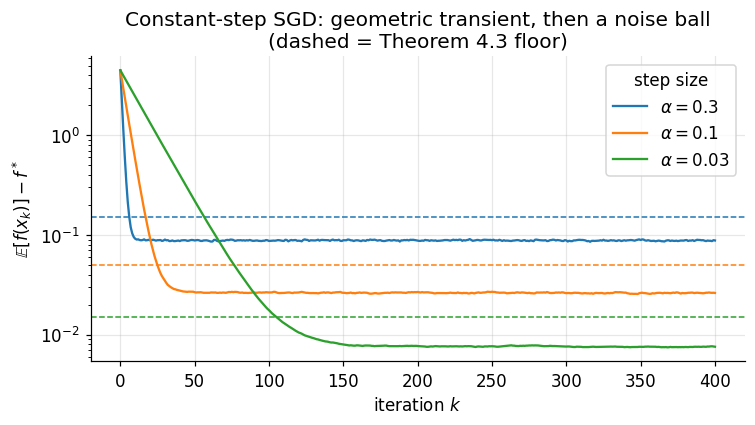

In [2]:
# f(x) = (mu/2) x^2 in 1-D: mu = L = 1, so the theory constants are exact.
mu = L_smooth = 1.0
sigma2 = 1.0            # variance of the additive gradient noise (B = 1)
n_runs, n_steps = 20000, 400
steps = np.arange(n_steps + 1)

fig, ax = plt.subplots()
for alpha, color in zip([0.30, 0.10, 0.03], ["C0", "C1", "C2"]):
    x = np.full(n_runs, 3.0)
    gap = [0.5 * np.mean(x**2)]
    for _ in range(n_steps):
        g = mu * x + rng.normal(0.0, np.sqrt(sigma2), size=n_runs)
        x = x - alpha * g
        gap.append(0.5 * np.mean(x**2))
    floor = L_smooth * alpha * sigma2 / (2 * mu)          # Theorem 4.3 noise floor
    ax.semilogy(steps, gap, color=color, label=rf"$\alpha={alpha}$")
    ax.axhline(floor, color=color, ls="--", lw=1.0)

ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$\mathbb{E}[f(x_k)] - f^*$")
ax.set_title("Constant-step SGD: geometric transient, then a noise ball\n(dashed = Theorem 4.3 floor)")
ax.legend(title="step size")
plt.tight_layout()
plt.show()

Each curve falls geometrically and then flattens, and every plateau sits below the dashed line
$L\alpha\sigma^2/(2\mu)$ of Theorem 4.3. Halving $\alpha$ halves the floor and slows the transient by the
same factor: the two regimes of Section 2.2, and the reason a decayed learning rate produces a visible
step down in a training curve.

## 3. Definitions

### Definition 3.1 (Finite-sum and expected risk)

For $f_i:\mathbb{R}^n\to\mathbb{R}$,

$$
f(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N f_i(\mathbf{x}), \qquad F(\mathbf{x}) = \mathbb{E}_{\xi}\left[f_\xi(\mathbf{x})\right]
$$

### Definition 3.2 (Stochastic gradient oracle)

A random vector $\mathbf{g}(\mathbf{x},\xi)$ is an **unbiased** stochastic gradient if

$$
\mathbb{E}_{\xi}\left[\mathbf{g}(\mathbf{x},\xi)\right] = \nabla f(\mathbf{x}) \qquad \text{for every } \mathbf{x}
$$

and has **variance bounded by $\sigma^2$** if
$\mathbb{E}_\xi\lVert \mathbf{g}(\mathbf{x},\xi)-\nabla f(\mathbf{x})\rVert^2 \le \sigma^2$.

### Definition 3.3 (Mini-batch estimator)

For an index multiset $\mathcal{B}$ of size $B$ drawn uniformly with replacement from $\{1,\dots,N\}$,

$$
\mathbf{g}_{\mathcal{B}}(\mathbf{x}) = \frac{1}{B}\sum_{i\in\mathcal{B}}\nabla f_i(\mathbf{x})
$$

### Definition 3.4 (Stochastic gradient descent)

Given step sizes $\alpha_k \gt 0$,

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha_k\,\mathbf{g}_k, \qquad \mathbb{E}\left[\mathbf{g}_k\mid\mathcal{F}_k\right] = \nabla f(\mathbf{x}_k)
$$

where $\mathcal{F}_k$ is the $\sigma$-algebra generated by everything up to iteration $k$.

### Definition 3.5 (Robbins-Monro conditions)

A step-size schedule $\{\alpha_k\}$ is **admissible** if

$$
\alpha_k \gt 0, \qquad \sum_{k=1}^{\infty}\alpha_k = \infty, \qquad \sum_{k=1}^{\infty}\alpha_k^2 \lt \infty
$$

Canonical example: $\alpha_k = \alpha_1 / k^{p}$ with $p \in (1/2,\ 1]$.

### Definition 3.6 (SVRG estimator)

With a *snapshot* $\tilde{\mathbf{x}}$ at which the full gradient $\nabla f(\tilde{\mathbf{x}})$ has been
computed, and $i$ drawn uniformly,

$$
\mathbf{g}^{\mathrm{SVRG}}(\mathbf{x}) = \nabla f_i(\mathbf{x}) - \nabla f_i(\tilde{\mathbf{x}}) + \nabla f(\tilde{\mathbf{x}})
$$

### Definition 3.7 (SGD with heavy-ball momentum)

$$
\mathbf{m}_{k+1} = \beta\mathbf{m}_k + \mathbf{g}_k, \qquad \mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\,\mathbf{m}_{k+1}
$$

### Definition 3.8 (AdaGrad and Adam)

AdaGrad accumulates squared gradients per coordinate,

$$
v_{k,j} = \sum_{t\le k}g_{t,j}^2, \qquad x_{k+1,j} = x_{k,j} - \frac{\alpha}{\sqrt{v_{k,j}}+\varepsilon}\,g_{k,j}
$$

Adam replaces the sums by exponential moving averages with bias correction,

$$
\mathbf{m}_k = \beta_1\mathbf{m}_{k-1} + (1-\beta_1)\mathbf{g}_k, \quad \mathbf{v}_k = \beta_2\mathbf{v}_{k-1} + (1-\beta_2)\mathbf{g}_k^{\odot2}
$$

$$
\hat{\mathbf{m}}_k = \frac{\mathbf{m}_k}{1-\beta_1^k}, \quad \hat{\mathbf{v}}_k = \frac{\mathbf{v}_k}{1-\beta_2^k}, \qquad \mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\,\frac{\hat{\mathbf{m}}_k}{\sqrt{\hat{\mathbf{v}}_k}+\varepsilon}
$$

with $\mathbf{m}_0 = \mathbf{v}_0 = \mathbf{0}$ and $\varepsilon \gt 0$.

## 4. Main Results

### Theorem 4.1 (Unbiasedness and the $1/B$ variance law)

Let $\mathcal{B}$ be $B$ indices drawn i.i.d. uniformly from $\{1,\dots,N\}$, and suppose the
per-example gradient spread at $\mathbf{x}$ is
$\frac{1}{N}\sum_i\lVert \nabla f_i(\mathbf{x})-\nabla f(\mathbf{x})\rVert^2 = \sigma^2(\mathbf{x}) \lt \infty$.
Then

$$
\boxed{\ \mathbb{E}\left[\mathbf{g}_{\mathcal{B}}(\mathbf{x})\right] = \nabla f(\mathbf{x}), \qquad \mathbb{E}\left\lVert \mathbf{g}_{\mathcal{B}}(\mathbf{x})-\nabla f(\mathbf{x})\right\rVert^2 = \frac{\sigma^2(\mathbf{x})}{B}\ }
$$

If instead $\mathcal{B}$ is a uniform random *subset* of size $B$ (sampling without replacement), the
variance carries the finite-population correction $\frac{N-B}{N-1}$ and vanishes at $B = N$.

**Interpretation.** The batch gradient is a sample mean, so it inherits the sample-mean variance law
exactly: variance $\propto 1/B$, standard deviation $\propto 1/\sqrt{B}$. The consequence is the one that
governs every batch-size decision: a batch costs $B$ gradient evaluations and buys a factor $B$ in
variance, so *accuracy per unit compute is constant* and $B$ is a scheduling choice, not an accuracy
choice.

*Why the hypotheses are needed.* Uniform sampling is what makes the finite sum an expectation, without
which the estimator is biased; i.i.d. draws are what kill the cross terms in Step 4 of Proof 5.1, and
dropping them is exactly what produces the finite-population correction; finiteness of
$\sigma^2(\mathbf{x})$ is what makes the second moment exist at all.

### Theorem 4.2 (Expected descent inequality)

Let $f$ be $L$-smooth ($\lVert \nabla f(\mathbf{x})-\nabla f(\mathbf{y})\rVert \le L\lVert \mathbf{x}-\mathbf{y}\rVert$),
let $\mathbf{g}_k$ be unbiased with conditional variance at most $\sigma_B^2 = \sigma^2/B$, and let
$\alpha \gt 0$ be constant. Then

$$
\boxed{\ \mathbb{E}\left[f(\mathbf{x}_{k+1})\mid\mathcal{F}_k\right] \le f(\mathbf{x}_k) - \alpha\left(1-\frac{L\alpha}{2}\right)\lVert \nabla f(\mathbf{x}_k)\rVert^2 + \frac{L\alpha^2\sigma_B^2}{2}\ }
$$

**Interpretation.** One SGD step buys $\alpha(1-L\alpha/2)\lVert \nabla f\rVert^2$ of descent and pays
$L\alpha^2\sigma_B^2/2$ of noise. Because the payment survives at $\nabla f(\mathbf{x}_k) = \mathbf{0}$,
a fixed step size cannot stop at the optimum: the noise ball of Theorem 4.3 is forced by this one line.

*Why the hypotheses are needed.* $L$-smoothness is what bounds the second-order remainder by
$\frac{L}{2}\lVert \cdot \rVert^2$, and without it the step could overshoot arbitrarily; unbiasedness is
what turns $-\alpha\nabla f^\top\mathbf{g}_k$ into $-\alpha\lVert \nabla f\rVert^2$, so a biased oracle
loses the descent term; the variance bound is what makes the last term finite.

### Theorem 4.3 (Constant step: linear convergence to a noise ball)

Let $f$ be $L$-smooth and $\mu$-strongly convex with minimum $f^*$, let $\mathbf{g}_k$ be unbiased with
conditional variance at most $\sigma_B^2$, and let $0 \lt \alpha \le 1/L$. Then for every $k \ge 0$,

$$
\boxed{\ \mathbb{E}\left[f(\mathbf{x}_k)\right] - f^* \le (1-\alpha\mu)^k\left(f(\mathbf{x}_0)-f^*\right) + \frac{L\alpha\sigma_B^2}{2\mu}\ }
$$

**Interpretation.** Training is a race between a geometric term that dies and a constant floor that does
not. The floor $\frac{L\alpha\sigma^2}{2\mu B}$ names its own three remedies — decay $\alpha$, raise $B$,
or shrink $\sigma$ — and says they are interchangeable in exactly the ratio $\alpha/B$.

*Why the hypotheses are needed.* Strong convexity supplies the gradient-dominance inequality
$\lVert \nabla f\rVert^2 \ge 2\mu(f-f^*)$ that converts descent in gradient norm into descent in function
value, and without it only the stationarity rate of Theorem 4.6 survives; $\alpha \le 1/L$ is what makes
$1-L\alpha/2 \ge 1/2$, so a larger step can invert the sign of the descent term and diverge.

### Theorem 4.4 (Decreasing steps: $O(1/k)$ for strongly convex objectives)

Let $f$ be $\mu$-strongly convex with minimizer $\mathbf{x}^*$, let the oracle satisfy
$\mathbb{E}\left[\lVert \mathbf{g}_k\rVert^2 \mid \mathcal{F}_k\right] \le G^2$, and take
$\alpha_k = \frac{1}{\mu k}$ for $k \ge 1$. Then

$$
\boxed{\ a_k := \mathbb{E}\left\lVert \mathbf{x}_k - \mathbf{x}^*\right\rVert^2 \le \frac{2G^2}{\mu^2 k} \qquad (k \ge 1)\ }
$$

and if $f$ is also $L$-smooth, $\mathbb{E}[f(\mathbf{x}_k)] - f^* \le \frac{LG^2}{\mu^2k} = O(1/k)$.

The constant $2$ is not cosmetic: the sharper claim $a_k \le G^2/(\mu^2k)$ is **false**. Take
$f(x) = \frac{\mu}{2}x^2$, $x_0 = x^* = 0$, an oracle that returns $g_0 = 0$ and then
$g_1 = \pm G$ with probability $\tfrac12$ each (both obey $\mathbb{E}[g_k^2] \le G^2$). Then $a_1 = 0$ but
$a_2 = \alpha_1^2G^2 = G^2/\mu^2$, which exceeds $G^2/(2\mu^2)$.

**Interpretation.** Shrinking the step like $1/k$ shrinks the ball as fast as the iterate approaches it,
and $O(1/k)$ in squared distance — i.e. $O(1/\sqrt{k})$ in distance — is the price of noise. The rate is
*minimax optimal*: by the Nemirovski-Yudin lower bound no method using only unbiased noisy gradients can
beat $\Omega(1/k)$ on this class, so the schedule is not merely convenient but final.

*Why the hypotheses are needed.* Strong convexity gives the strong-monotonicity bound
$\nabla f(\mathbf{x}_k)^\top(\mathbf{x}_k-\mathbf{x}^*) \ge \mu\lVert \mathbf{x}_k-\mathbf{x}^*\rVert^2$
that produces the contraction factor $1-2\mu\alpha_k$; the second-moment bound $G^2$ is what keeps the
injected term summable against $\alpha_k^2$; the constant $1/\mu$ in the schedule is what makes
$2\mu\alpha_k = 2/k$, and a schedule $c/(\mu k)$ with $c \lt 1/2$ contracts too slowly for the induction
to close at rate $1/k$.

### Theorem 4.5 (Robbins-Monro: almost-sure convergence)

Let $f$ be convex and differentiable with a **unique** minimizer $\mathbf{x}^*$, let the oracle be
unbiased with $\mathbb{E}\left[\lVert \mathbf{g}_k\rVert^2\mid\mathcal{F}_k\right] \le G^2$, and let
$\{\alpha_k\}$ be admissible in the sense of Definition 3.5. Then the iterates of Definition 3.4 satisfy

$$
\boxed{\ \mathbf{x}_k \longrightarrow \mathbf{x}^* \quad \text{almost surely}\ }
$$

**Interpretation.** Theorems 4.3 and 4.4 control *averages*; this controls *every run*. It is the
statement that a single training trajectory, not a hypothetical ensemble of them, actually arrives — and
it is what the two Robbins-Monro conditions were invented to deliver.

*Why the hypotheses are needed.* $\sum_k\alpha_k^2 \lt \infty$ is what makes the injected noise energy
summable, so Lemma 4.11 applies and $\lVert \mathbf{x}_k-\mathbf{x}^*\rVert^2$ converges; $\sum_k\alpha_k =
\infty$ is what forces $\liminf_k\left(f(\mathbf{x}_k)-f^*\right) = 0$, and a summable schedule can leave
the iterate stranded (Section 7.3 runs that failure); uniqueness of the minimizer is what identifies the
limit, since with a flat set of minimizers the iterates still converge, but to a random point of that set.

### Theorem 4.6 (Nonconvex stationarity rate)

Let $f$ be $L$-smooth and bounded below by $f^*$, let $\mathbf{g}_k$ be unbiased with conditional variance
at most $\sigma_B^2$, and run $K$ steps with the constant step
$\alpha = \min\left\{\frac{1}{L},\ \frac{1}{\sigma_B}\sqrt{\frac{2\Delta_0}{LK}}\right\}$ where
$\Delta_0 = f(\mathbf{x}_0)-f^*$. Then

$$
\boxed{\ \frac{1}{K}\sum_{k=0}^{K-1}\mathbb{E}\left\lVert \nabla f(\mathbf{x}_k)\right\rVert^2 \le \frac{4L\Delta_0}{K} + 2\sigma_B\sqrt{\frac{2L\Delta_0}{K}} = O\!\left(\frac{1}{\sqrt{K}}\right)\ }
$$

so $O(\epsilon^{-4})$ stochastic gradient evaluations suffice for
$\mathbb{E}\lVert \nabla f\rVert \le \epsilon$, against $O(\epsilon^{-2})$ for exact gradients.

**Interpretation.** Without convexity the only quantity that can be driven down is the gradient norm, and
noise degrades the exponent from $1/K$ to $1/\sqrt{K}$. The extra two powers of $\epsilon$ are the entire
reason deep-learning runs are measured in millions of steps.

*Why the hypotheses are needed.* $L$-smoothness supplies Theorem 4.2, the only inequality available
without convexity; boundedness below is what makes the telescoped sum finite; the step size must be
$O(1/\sqrt{K})$ because a constant step leaves an $\alpha\sigma_B^2$ floor that no averaging removes.

### Theorem 4.7 (SVRG variance reduction)

Let each $f_i$ be convex and $L$-smooth, let $f = \frac1N\sum_i f_i$ have minimum $f^*$, and let
$\mathbf{g}^{\mathrm{SVRG}}$ be the estimator of Definition 3.6. Then it is unbiased and

$$
\boxed{\ \mathbb{E}\left\lVert \mathbf{g}^{\mathrm{SVRG}}(\mathbf{x})-\nabla f(\mathbf{x})\right\rVert^2 \le 4L\left[\left(f(\mathbf{x})-f^*\right)+\left(f(\tilde{\mathbf{x}})-f^*\right)\right]\ }
$$

Consequently, on $\mu$-strongly convex finite sums SVRG converges **linearly**, with
$O\!\left((N+\kappa)\log(1/\epsilon)\right)$ gradient evaluations for $\kappa = L/\mu$.

**Interpretation.** The variance is no longer a constant floor but a quantity proportional to the
suboptimality, so the noise ball collapses as the iterate approaches the optimum. That single change
converts the $O(\sigma^2/(\mu\epsilon))$ complexity of SGD into a logarithmic one — at the price of one
full-gradient snapshot per epoch.

*Why the hypotheses are needed.* Convexity plus $L$-smoothness of each *individual* $f_i$ is what supplies
the co-coercivity bound of Step 4 in Proof 5.7; smoothness of the average alone is not enough. The snapshot
must be a point at which the *exact* full gradient was computed, since that is what makes the control
variate have known mean.

### Theorem 4.8 (Momentum: effective step and effective averaging window)

Run Definition 3.7 with $\mathbf{m}_0 = \mathbf{0}$ and $\beta \in [0,1)$. If the gradients are constant,
$\mathbf{g}_t \equiv \mathbf{g}$, the update converges to a fixed step

$$
\boxed{\ \alpha_{\mathrm{eff}} = \frac{\alpha}{1-\beta}\ }
$$

and if the $\mathbf{g}_t$ are instead unbiased, mutually independent and of variance $\sigma_B^2$, the
normalized buffer satisfies $\operatorname{Var}\left[(1-\beta)\mathbf{m}_k\right] \to \frac{1-\beta}{1+\beta}\sigma_B^2$,
an effective average over $\frac{1+\beta}{1-\beta}$ samples.

**Interpretation.** Momentum does two things at once, and both scale with $1/(1-\beta)$: it multiplies the
step, which is why raising $\beta$ from $0.9$ to $0.99$ without lowering $\alpha$ makes training explode,
and it averages $19$ gradients at $\beta = 0.9$, which is why it also reduces variance.

*Why the hypotheses are needed.* $\beta \lt 1$ is what makes the geometric series converge; independence
of the $\mathbf{g}_t$ is an idealization — correlated gradients make the effective window shorter, so the
formula is an upper bound on the variance reduction actually obtained.

### Theorem 4.9 (Adam bias correction)

Run Definition 3.8 with $\mathbf{v}_0 = \mathbf{0}$ and suppose the second moments are stationary,
$\mathbb{E}\left[\mathbf{g}_t^{\odot2}\right] = \mathbb{E}\left[\mathbf{g}^{\odot2}\right]$ for all $t$. Then

$$
\boxed{\ \mathbb{E}\left[\mathbf{v}_k\right] = \left(1-\beta_2^{\,k}\right)\mathbb{E}\left[\mathbf{g}^{\odot2}\right] \quad\Longrightarrow\quad \mathbb{E}\left[\hat{\mathbf{v}}_k\right] = \mathbb{E}\left[\mathbf{g}^{\odot2}\right]\ }
$$

and the identical computation with $\beta_1$ gives $\mathbb{E}[\hat{\mathbf{m}}_k] = \mathbb{E}[\mathbf{g}]$.

**Interpretation.** The bias is not a modelling approximation but pure bookkeeping: the buffer starts at an
artificial zero and has only accumulated a fraction $1-\beta_2^k$ of its stationary mass. Dividing that
fraction out is exact, and at $k=1$ with $\beta_2 = 0.999$ it is a $1000\times$ rescaling — which is why
an uncorrected Adam takes an enormous first step.

*Why the hypotheses are needed.* Stationarity is what lets $\mathbb{E}[\mathbf{g}_t^{\odot2}]$ come out of
the sum; under a drifting gradient scale the correction is only approximate. The zero initialization is
what produces the factor in the first place: initializing $\mathbf{v}_0$ at the first observed
$\mathbf{g}_1^{\odot2}$ removes the bias without any correction.

### Theorem 4.10 (Polyak-Juditsky averaging — cited, not proved here)

Let $f$ be twice differentiable near $\mathbf{x}^*$ with $H = \nabla^2f(\mathbf{x}^*) \succ 0$, let the
oracle noise have covariance $\Sigma$ at $\mathbf{x}^*$, and take $\alpha_k = \alpha_1k^{-p}$ with
$p \in (1/2,1)$. Then the average $\bar{\mathbf{x}}_K = \frac{1}{K}\sum_{k \lt K}\mathbf{x}_k$ satisfies

$$
\sqrt{K}\left(\bar{\mathbf{x}}_K - \mathbf{x}^*\right) \xrightarrow{\ d\ } \mathcal{N}\!\left(\mathbf{0},\ H^{-1}\Sigma H^{-1}\right)
$$

which is the asymptotic covariance of the maximum-likelihood estimator — statistically optimal, and
attained without ever forming $H$.

Proof: Polyak & Juditsky, *SIAM J. Control Optim.* **30**(4) (1992), Theorem 2 and Theorem 4, pp. 845-849.
The strongest special case this module supports — a one-dimensional quadratic, where the averaged variance
is computed in closed form and beats the last iterate by an explicit factor — is worked out in
[`exercises.ipynb`](exercises.ipynb), Problem L3.1.

**Interpretation.** The last iterate of a decaying-step run still carries $O(\alpha_k)$ of fresh noise;
the running average filters it, and the residual is precisely the statistical noise floor of the estimation
problem itself. Exponential moving averages of weights and stochastic weight averaging are this theorem
in engineering form.

### Lemma 4.11 (Robbins-Siegmund supermartingale convergence — cited, not proved here)

Let $\{a_k\}$, $\{b_k\}$, $\{u_k\}$ be non-negative random variables adapted to a filtration
$\{\mathcal{F}_k\}$ with

$$
\mathbb{E}\left[a_{k+1}\mid\mathcal{F}_k\right] \le a_k - u_k + b_k \qquad \text{and} \qquad \sum_{k}b_k \lt \infty \ \text{ a.s.}
$$

Then, almost surely, $a_k$ converges to a finite limit and $\sum_k u_k \lt \infty$.

Proof: Robbins & Siegmund, "A convergence theorem for non negative almost supermartingales and some
applications", in *Optimizing Methods in Statistics* (Academic Press, 1971), Theorem 1, pp. 233-235; the
argument is Doob's supermartingale convergence theorem applied to $a_k + \sum_{j\lt k}(u_j-b_j)$.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Step 1 (unbiasedness of a single draw).** For $i$ uniform on $\{1,\dots,N\}$,

$$
\mathbb{E}\left[\nabla f_i(\mathbf{x})\right] = \sum_{j=1}^N \frac{1}{N}\nabla f_j(\mathbf{x}) = \nabla f(\mathbf{x})
$$

This is nothing but the statement that the finite sum *is* an expectation under the uniform distribution.

**Step 2 (unbiasedness of the batch).** By linearity of expectation,

$$
\mathbb{E}\left[\mathbf{g}_{\mathcal{B}}\right] = \frac{1}{B}\sum_{r=1}^{B}\mathbb{E}\left[\nabla f_{i_r}\right] = \frac{1}{B}\cdot B\,\nabla f(\mathbf{x}) = \nabla f(\mathbf{x})
$$

**Step 3 (variance of a single draw).** Put $\boldsymbol{\epsilon}_i = \nabla f_i(\mathbf{x})-\nabla f(\mathbf{x})$,
so $\mathbb{E}[\boldsymbol{\epsilon}_i] = \mathbf{0}$ and

$$
\mathbb{E}\lVert \boldsymbol{\epsilon}_i\rVert^2 = \frac{1}{N}\sum_{j=1}^N\left\lVert \nabla f_j(\mathbf{x})-\nabla f(\mathbf{x})\right\rVert^2 = \sigma^2(\mathbf{x})
$$

**Step 4 (independence kills the cross terms).**

$$
\mathbb{E}\left\lVert \mathbf{g}_{\mathcal{B}}-\nabla f\right\rVert^2 = \frac{1}{B^2}\,\mathbb{E}\left\lVert \sum_{r=1}^B\boldsymbol{\epsilon}_{i_r}\right\rVert^2 = \frac{1}{B^2}\left[\sum_{r}\mathbb{E}\lVert \boldsymbol{\epsilon}_{i_r}\rVert^2 + \sum_{r\neq s}\underbrace{\mathbb{E}\left[\boldsymbol{\epsilon}_{i_r}^\top\boldsymbol{\epsilon}_{i_s}\right]}_{= \mathbb{E}[\boldsymbol{\epsilon}_{i_r}]^\top\mathbb{E}[\boldsymbol{\epsilon}_{i_s}] = 0}\right] = \frac{B\sigma^2}{B^2} = \frac{\sigma^2}{B}
$$

**Step 5 (without replacement).** If $\mathcal{B}$ is a uniform random subset of size $B$ the draws are
negatively correlated. Writing $\mathbb{E}[\boldsymbol{\epsilon}_{i_r}^\top\boldsymbol{\epsilon}_{i_s}] = -\frac{\sigma^2}{N-1}$
for $r\ne s$ (because $\sum_{i}\boldsymbol{\epsilon}_i = \mathbf{0}$ forces
$\sum_{i\ne j}\boldsymbol{\epsilon}_i^\top\boldsymbol{\epsilon}_j = -N\sigma^2$) and repeating Step 4,

$$
\mathbb{E}\left\lVert \mathbf{g}_{\mathcal{B}}-\nabla f\right\rVert^2 = \frac{1}{B^2}\left[B\sigma^2 - B(B-1)\frac{\sigma^2}{N-1}\right] = \frac{\sigma^2}{B}\cdot\frac{N-B}{N-1}
$$

which correctly gives $0$ at $B = N$: the full gradient is exact. $\blacksquare$

**Reading the law.** Variance falls like $1/B$ but the *standard deviation* only like $1/\sqrt{B}$, while
compute grows like $B$. Accuracy per unit compute is therefore constant — the fact behind every batch-size
argument in Section 7.1.

### Proof 5.2 (of Theorem 4.2)

**Step 1 (descent lemma).** $L$-smoothness gives, for any $\mathbf{y}$,

$$
f(\mathbf{y}) \le f(\mathbf{x}_k) + \nabla f(\mathbf{x}_k)^\top(\mathbf{y}-\mathbf{x}_k) + \frac{L}{2}\lVert \mathbf{y}-\mathbf{x}_k\rVert^2
$$

Apply it at $\mathbf{y} = \mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\mathbf{g}_k$:

$$
f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \alpha\,\nabla f(\mathbf{x}_k)^\top\mathbf{g}_k + \frac{L\alpha^2}{2}\lVert \mathbf{g}_k\rVert^2
$$

**Step 2 (take the conditional expectation).** Using $\mathbb{E}[\mathbf{g}_k\mid\mathcal{F}_k] = \nabla f(\mathbf{x}_k)$
for the linear term,

$$
\mathbb{E}\left[\nabla f(\mathbf{x}_k)^\top\mathbf{g}_k\mid\mathcal{F}_k\right] = \lVert \nabla f(\mathbf{x}_k)\rVert^2
$$

**Step 3 (the second moment splits).** The bias-variance decomposition for a random vector gives

$$
\mathbb{E}\left[\lVert \mathbf{g}_k\rVert^2\mid\mathcal{F}_k\right] = \left\lVert \mathbb{E}[\mathbf{g}_k\mid\mathcal{F}_k]\right\rVert^2 + \mathbb{E}\left[\lVert \mathbf{g}_k-\nabla f(\mathbf{x}_k)\rVert^2\mid\mathcal{F}_k\right] \le \lVert \nabla f(\mathbf{x}_k)\rVert^2 + \sigma_B^2
$$

**Step 4 (assemble).**

$$
\mathbb{E}\left[f(\mathbf{x}_{k+1})\mid\mathcal{F}_k\right] \le f(\mathbf{x}_k) - \alpha\lVert \nabla f_k\rVert^2 + \frac{L\alpha^2}{2}\left(\lVert \nabla f_k\rVert^2 + \sigma_B^2\right)
$$

Collecting the $\lVert \nabla f_k\rVert^2$ terms yields the claim. $\blacksquare$

**Two readings.**

Setting $\sigma_B = 0$ recovers the deterministic descent inequality, with the familiar requirement
$\alpha \lt 2/L$ for the coefficient $\alpha(1-L\alpha/2)$ to be positive.

With $\sigma_B \gt 0$, no choice of $\alpha$ makes the right side smaller than
$f(\mathbf{x}_k) + \frac{L\alpha^2\sigma_B^2}{2}$ once $\nabla f(\mathbf{x}_k) = \mathbf{0}$: the algorithm
keeps moving at the optimum. Hence the noise ball is unavoidable at fixed $\alpha$.

### Proof 5.3 (of Theorem 4.3)

**Step 1 (simplify the descent inequality).** With $\alpha \le 1/L$ we have $1 - \frac{L\alpha}{2} \ge \frac12$,
so Theorem 4.2 gives

$$
\mathbb{E}\left[f(\mathbf{x}_{k+1})\mid\mathcal{F}_k\right] \le f(\mathbf{x}_k) - \frac{\alpha}{2}\lVert \nabla f(\mathbf{x}_k)\rVert^2 + \frac{L\alpha^2\sigma_B^2}{2}
$$

**Step 2 (gradient dominance from strong convexity).** Minimizing both sides of
$f(\mathbf{y}) \ge f(\mathbf{x}) + \nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x}) + \frac{\mu}{2}\lVert \mathbf{y}-\mathbf{x}\rVert^2$
over $\mathbf{y}$ gives $f^* \ge f(\mathbf{x}) - \frac{1}{2\mu}\lVert \nabla f(\mathbf{x})\rVert^2$, i.e.

$$
\lVert \nabla f(\mathbf{x})\rVert^2 \ge 2\mu\left(f(\mathbf{x})-f^*\right)
$$

Substituting,

$$
\mathbb{E}\left[f(\mathbf{x}_{k+1})\mid\mathcal{F}_k\right] - f^* \le \left(1-\alpha\mu\right)\left(f(\mathbf{x}_k)-f^*\right) + \frac{L\alpha^2\sigma_B^2}{2}
$$

**Step 3 (unroll the affine recursion).** Write $\delta_k = \mathbb{E}[f(\mathbf{x}_k)]-f^*$,
$\rho = 1-\alpha\mu \in [0,1)$ and $c = \frac{L\alpha^2\sigma_B^2}{2}$. Taking total expectations,
$\delta_{k+1} \le \rho\,\delta_k + c$, hence

$$
\delta_k \le \rho^k\delta_0 + c\sum_{j=0}^{k-1}\rho^{j} \le \rho^k\delta_0 + \frac{c}{1-\rho} = (1-\alpha\mu)^k\delta_0 + \frac{L\alpha\sigma_B^2}{2\mu}
$$

using $\frac{c}{1-\rho} = \frac{L\alpha^2\sigma_B^2}{2\alpha\mu} = \frac{L\alpha\sigma_B^2}{2\mu}$. $\blacksquare$

**Step 4 (the fixed point is the noise ball).** The recursion's fixed point
$\delta_\infty = \frac{c}{1-\rho} = \frac{L\alpha\sigma^2}{2\mu B}$ is exactly the balance predicted in
Section 2.2. Three levers shrink it, each with a different cost:

$$
\delta_\infty \propto \frac{\alpha\,\sigma^2}{\mu\,B}: \quad \text{halve } \alpha \ (\text{slower transient}), \quad \text{double } B \ (\text{2}\times\text{ compute per step}), \quad \text{reduce } \sigma \ (\text{SVRG})
$$

**Step 5 (a schedule from the bound).** Halving $\alpha$ each time the loss plateaus makes $\delta$ track a
staircase: each drop in $\alpha$ halves the floor and the run resumes its geometric transient. This is the
theoretical justification for step-decay learning-rate schedules.

### Proof 5.4 (of Theorem 4.4)

**Step 1 (expand the squared distance).**

$$
\lVert \mathbf{x}_{k+1}-\mathbf{x}^*\rVert^2 = \lVert \mathbf{x}_k-\mathbf{x}^*\rVert^2 - 2\alpha_k\,\mathbf{g}_k^\top\left(\mathbf{x}_k-\mathbf{x}^*\right) + \alpha_k^2\lVert \mathbf{g}_k\rVert^2
$$

**Step 2 (condition and use unbiasedness).**

$$
\mathbb{E}\left[\mathbf{g}_k^\top(\mathbf{x}_k-\mathbf{x}^*)\mid\mathcal{F}_k\right] = \nabla f(\mathbf{x}_k)^\top\left(\mathbf{x}_k-\mathbf{x}^*\right)
$$

**Step 3 (strong monotonicity).** Strong convexity gives, with $\nabla f(\mathbf{x}^*) = \mathbf{0}$,

$$
\nabla f(\mathbf{x}_k)^\top\left(\mathbf{x}_k-\mathbf{x}^*\right) = \left(\nabla f(\mathbf{x}_k)-\nabla f(\mathbf{x}^*)\right)^\top\left(\mathbf{x}_k-\mathbf{x}^*\right) \ge \mu\lVert \mathbf{x}_k-\mathbf{x}^*\rVert^2
$$

**Step 4 (the recursion).** Combining and taking total expectations,

$$
a_{k+1} \le \left(1 - 2\mu\alpha_k\right)a_k + \alpha_k^2G^2
$$

**Step 5 (induction with $\alpha_k = 1/(\mu k)$).** Let $Q = G^2/\mu^2$; the claim is $a_k \le 2Q/k$ for
all $k \ge 1$. Substituting $\alpha_k = 1/(\mu k)$ into Step 4 gives the concrete recursion

$$
a_{k+1} \le \left(1-\frac{2}{k}\right)a_k + \frac{Q}{k^2}, \qquad k \ge 1
$$

*Base case $k = 1$.* The first update leaves $\mathbf{x}_0$ with the schedule's own value
$\alpha_1 = 1/\mu$, so Step 4 applied to that update reads

$$
a_1 \le \left(1-2\mu\alpha_1\right)a_0 + \alpha_1^2G^2 = -a_0 + Q \le Q \le 2Q
$$

since $a_0 = \lVert \mathbf{x}_0-\mathbf{x}^*\rVert^2 \ge 0$. No initialization convention and no undefined
$\alpha_0$ are used.

*Inductive step, $k = 1$.* Here $1 - 2/k = -1 \lt 0$, so the recursion is *decreasing* in $a_k$ and the
inductive hypothesis may not be substituted; use $a_1 \ge 0$ instead:

$$
a_2 \le -a_1 + Q \le Q = \frac{2Q}{2}
$$

*Inductive step, $k = 2$.* Here $1 - 2/k = 0$, so $a_3 \le Q/4 \le 2Q/3$.

*Inductive step, $k \ge 3$.* Now $1 - 2/k \ge 1/3 \gt 0$, the right side is increasing in $a_k$, and the
hypothesis $a_k \le 2Q/k$ may be substituted:

$$
a_{k+1} \le \left(1-\frac{2}{k}\right)\frac{2Q}{k} + \frac{Q}{k^2} = Q\,\frac{2k-4+1}{k^2} = Q\,\frac{2k-3}{k^2}
$$

and $\frac{2k-3}{k^2} \le \frac{2}{k+1}$ because $(2k-3)(k+1) = 2k^2-k-3 \le 2k^2$. Hence
$a_{k+1} \le \frac{2Q}{k+1}$ in every case, completing the induction. $\blacksquare$

**Where the sign of $1-2/k$ matters.** Substituting the inductive hypothesis blindly at $k = 1$ — where
the coefficient is negative — would "prove" $a_2 \le Q/2$, and the counterexample recorded with Theorem
4.4 shows that conclusion is false. The three-case split above is what the negative coefficient forces.

**Step 6 (why both Robbins-Monro conditions are needed).**

$\sum_k\alpha_k = \infty$: the total distance the drift term can cover is $O(\sum_k\alpha_k)$, so a
summable schedule such as $\alpha_k = 2^{-k}$ can leave the iterate stranded far from $\mathbf{x}^*$
forever.

$\sum_k\alpha_k^2 \lt \infty$: the accumulated injected noise energy is $O(\sigma^2\sum_k\alpha_k^2)$, and
if it diverges the iterate never settles. The harmonic schedule $\alpha_k \propto 1/k$ sits just inside
both conditions, and $\alpha_k \propto k^{-p}$ works for $p\in(1/2,1]$.

### Proof 5.5 (of Theorem 4.5)

**Step 1 (the one-step inequality).** Let $a_k = \lVert \mathbf{x}_k-\mathbf{x}^*\rVert^2$. Steps 1-2 of
Proof 5.4, together with the convexity inequality
$\nabla f(\mathbf{x}_k)^\top(\mathbf{x}_k-\mathbf{x}^*) \ge f(\mathbf{x}_k)-f^*$ and
$\mathbb{E}[\lVert \mathbf{g}_k\rVert^2\mid\mathcal{F}_k] \le G^2$, give

$$
\mathbb{E}\left[a_{k+1}\mid\mathcal{F}_k\right] \le a_k - \underbrace{2\alpha_k\left(f(\mathbf{x}_k)-f^*\right)}_{=:\,u_k \ \ge 0} + \underbrace{\alpha_k^2G^2}_{=:\,b_k}
$$

**Step 2 (apply Lemma 4.11).** $\sum_k b_k = G^2\sum_k\alpha_k^2 \lt \infty$ by admissibility, so almost
surely $a_k$ converges to a finite limit $a_\infty$ and

$$
\sum_{k=1}^\infty \alpha_k\left(f(\mathbf{x}_k)-f^*\right) \lt \infty \quad \text{a.s.}
$$

**Step 3 ($\liminf$ of the suboptimality is zero).** Suppose on some event of positive probability
$\liminf_k\left(f(\mathbf{x}_k)-f^*\right) = 2\eta \gt 0$. Then $f(\mathbf{x}_k)-f^* \ge \eta$ for all
$k \ge k_0$, so $\sum_{k\ge k_0}\alpha_k(f(\mathbf{x}_k)-f^*) \ge \eta\sum_{k \ge k_0}\alpha_k = \infty$,
contradicting Step 2. Hence $\liminf_k\left(f(\mathbf{x}_k)-f^*\right) = 0$ a.s.

**Step 4 (identify the limit).** Fix a sample path in the full-measure event of Steps 2-3. Since $a_k$
converges, the sequence $\{\mathbf{x}_k\}$ is bounded. Take a subsequence with
$f(\mathbf{x}_{k_j}) \to f^*$; by boundedness, pass to a further subsequence with
$\mathbf{x}_{k_j} \to \bar{\mathbf{x}}$. Continuity of $f$ gives $f(\bar{\mathbf{x}}) = f^*$, so
$\bar{\mathbf{x}}$ is a minimizer, and by uniqueness $\bar{\mathbf{x}} = \mathbf{x}^*$. Along that
subsequence $a_{k_j} = \lVert \mathbf{x}_{k_j}-\mathbf{x}^*\rVert^2 \to 0$.

**Step 5 (conclude).** A convergent sequence whose limit is approached along one subsequence has that
subsequential value as its limit: $a_\infty = 0$, i.e. $\mathbf{x}_k \to \mathbf{x}^*$ almost surely.
$\blacksquare$

**What each condition did.** $\sum_k\alpha_k^2 \lt \infty$ entered only in Step 2, to make the injected
noise summable; $\sum_k\alpha_k = \infty$ entered only in Step 3, to forbid a stalled trajectory. Neither
condition alone suffices, which is the precise sense in which Definition 3.5 is not bookkeeping.

### Proof 5.6 (of Theorem 4.6)

**Step 1 (start from the descent inequality).** With $\alpha \le 1/L$, Step 1 of Proof 5.3 gives, without
using convexity anywhere,

$$
\mathbb{E}\left[f(\mathbf{x}_{k+1})\mid\mathcal{F}_k\right] \le f(\mathbf{x}_k) - \frac{\alpha}{2}\lVert \nabla f(\mathbf{x}_k)\rVert^2 + \frac{L\alpha^2\sigma_B^2}{2}
$$

**Step 2 (telescope).** Take total expectations, rearrange, and sum over $k = 0,\dots,K-1$:

$$
\frac{\alpha}{2}\sum_{k=0}^{K-1}\mathbb{E}\lVert \nabla f(\mathbf{x}_k)\rVert^2 \le \left(f(\mathbf{x}_0) - \mathbb{E}\left[f(\mathbf{x}_K)\right]\right) + \frac{KL\alpha^2\sigma_B^2}{2} \le \Delta_0 + \frac{KL\alpha^2\sigma_B^2}{2}
$$

using $\mathbb{E}[f(\mathbf{x}_K)] \ge f^*$ and $\Delta_0 = f(\mathbf{x}_0)-f^*$.

**Step 3 (divide).**

$$
\frac{1}{K}\sum_{k=0}^{K-1}\mathbb{E}\lVert \nabla f(\mathbf{x}_k)\rVert^2 \le \frac{2\Delta_0}{\alpha K} + L\alpha\sigma_B^2
$$

**Step 4 (optimize the step size).** The right side is the sum of a decreasing and an increasing function
of $\alpha$; its unconstrained minimizer is
$\alpha^\star = \frac{1}{\sigma_B}\sqrt{\frac{2\Delta_0}{LK}}$.

*Case A: $\alpha = \alpha^\star \le 1/L$.* Substituting gives
$\sigma_B\sqrt{2L\Delta_0/K} + \sigma_B\sqrt{2L\Delta_0/K} = 2\sigma_B\sqrt{2L\Delta_0/K}$.

*Case B: $\alpha = 1/L \lt \alpha^\star$.* The inequality $1/L \lt \alpha^\star$ rearranges to
$\sigma_B^2 \le 2L\Delta_0/K$, so $L\alpha\sigma_B^2 = \sigma_B^2 \le 2L\Delta_0/K$, and the first term is
$2L\Delta_0/K$; the total is at most $4L\Delta_0/K$.

Adding the two cases gives the stated bound in both. $\blacksquare$

**Step 5 (reading the exponent).** To reach
$\frac1K\sum_k\mathbb{E}\lVert \nabla f_k\rVert^2 \le \epsilon^2$ the dominant term forces
$K = O(\sigma_B^2 L\Delta_0/\epsilon^4)$. Halving $\epsilon$ costs $16\times$ the compute, and the only
lever that does not is $\sigma_B^2 = \sigma^2/B$: doubling the batch halves $K$ at unchanged total cost,
which is why the stationarity rate is indifferent to batch size until the curvature ceiling of Section 7.1
intervenes.

### Proof 5.7 (of Theorem 4.7)

**Step 1 (unbiasedness).** With $i$ uniform and $\tilde{\mathbf{x}}$ fixed,

$$
\mathbb{E}\left[\mathbf{g}^{\mathrm{SVRG}}\right] = \underbrace{\mathbb{E}\left[\nabla f_i(\mathbf{x})\right]}_{=\nabla f(\mathbf{x})} - \underbrace{\mathbb{E}\left[\nabla f_i(\tilde{\mathbf{x}})\right]}_{=\nabla f(\tilde{\mathbf{x}})} + \nabla f(\tilde{\mathbf{x}}) = \nabla f(\mathbf{x})
$$

The last two terms form a **control variate**: a random quantity with known mean, subtracted to cancel
fluctuation without moving the mean.

**Step 2 (variance is bounded by a second moment).** Using
$\mathbb{E}\lVert \mathbf{z}-\mathbb{E}\mathbf{z}\rVert^2 \le \mathbb{E}\lVert \mathbf{z}\rVert^2$ applied
to $\mathbf{z} = \nabla f_i(\mathbf{x})-\nabla f_i(\tilde{\mathbf{x}})$, whose mean is
$\nabla f(\mathbf{x})-\nabla f(\tilde{\mathbf{x}})$,

$$
\mathbb{E}\left\lVert \mathbf{g}^{\mathrm{SVRG}}-\nabla f(\mathbf{x})\right\rVert^2 \le \mathbb{E}\left\lVert \nabla f_i(\mathbf{x})-\nabla f_i(\tilde{\mathbf{x}})\right\rVert^2
$$

**Step 3 (split around the optimum).** With
$\lVert \mathbf{u}+\mathbf{v}\rVert^2 \le 2\lVert \mathbf{u}\rVert^2 + 2\lVert \mathbf{v}\rVert^2$ applied
to $\mathbf{u} = \nabla f_i(\mathbf{x})-\nabla f_i(\mathbf{x}^*)$ and
$\mathbf{v} = \nabla f_i(\mathbf{x}^*)-\nabla f_i(\tilde{\mathbf{x}})$,

$$
\mathbb{E}\left\lVert \nabla f_i(\mathbf{x})-\nabla f_i(\tilde{\mathbf{x}})\right\rVert^2 \le 2\,\mathbb{E}\left\lVert \nabla f_i(\mathbf{x})-\nabla f_i(\mathbf{x}^*)\right\rVert^2 + 2\,\mathbb{E}\left\lVert \nabla f_i(\tilde{\mathbf{x}})-\nabla f_i(\mathbf{x}^*)\right\rVert^2
$$

**Step 4 (co-coercivity).** For convex $L$-smooth $h$ and any $\mathbf{x},\mathbf{y}$,

$$
\lVert \nabla h(\mathbf{x})-\nabla h(\mathbf{y})\rVert^2 \le 2L\left[h(\mathbf{x})-h(\mathbf{y})-\nabla h(\mathbf{y})^\top(\mathbf{x}-\mathbf{y})\right]
$$

Apply this to each $f_i$ at $\mathbf{y} = \mathbf{x}^*$ and average over $i$. The linear terms average to
$\frac1N\sum_i\nabla f_i(\mathbf{x}^*)^\top(\mathbf{x}-\mathbf{x}^*) = \nabla f(\mathbf{x}^*)^\top(\mathbf{x}-\mathbf{x}^*) = 0$,
leaving

$$
\mathbb{E}\left\lVert \nabla f_i(\mathbf{x})-\nabla f_i(\mathbf{x}^*)\right\rVert^2 \le 2L\left(f(\mathbf{x})-f^*\right)
$$

**Step 5 (combine).** Substituting the Step 4 bound at $\mathbf{x}$ and at $\tilde{\mathbf{x}}$ into
Step 3, and Step 3 into Step 2, gives $4L\left[(f(\mathbf{x})-f^*)+(f(\tilde{\mathbf{x}})-f^*)\right]$.
$\blacksquare$

**Step 6 (why this gives a linear rate).** As $\mathbf{x},\tilde{\mathbf{x}} \to \mathbf{x}^*$ both terms
vanish, so the effective $\sigma_B^2$ in Proof 5.3 **shrinks with the suboptimality** instead of remaining
a fixed floor. The noise ball collapses as the iterate approaches the optimum, and the total cost becomes

$$
O\!\left(\left(N + \kappa\right)\log\frac{1}{\epsilon}\right) \quad \text{versus} \quad O\!\left(\frac{\kappa\sigma^2}{\mu\epsilon}\right) \ \text{for plain SGD}
$$

The price is one full-gradient snapshot per epoch — worthwhile for moderate $N$ and high accuracy, rarely
used in deep learning where $N$ is enormous and $\epsilon$ is loose.

### Proof 5.8 (of Theorem 4.8)

**Step 1 (unroll the buffer).** From $\mathbf{m}_0 = \mathbf{0}$ and Definition 3.7,

$$
\mathbf{m}_{k} = \sum_{t=1}^{k}\beta^{\,k-t}\mathbf{g}_t, \qquad \mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\sum_{t=1}^{k+1}\beta^{\,k+1-t}\mathbf{g}_t
$$

**Step 2 (constant gradients).** If $\mathbf{g}_t \equiv \mathbf{g}$ then
$\mathbf{m}_k = \mathbf{g}\sum_{j=0}^{k-1}\beta^{j} \to \frac{\mathbf{g}}{1-\beta}$ because $\beta \lt 1$,
so the steady-state displacement per step is $\frac{\alpha}{1-\beta}\mathbf{g}$, i.e.
$\alpha_{\mathrm{eff}} = \alpha/(1-\beta)$.

**Step 3 (variance of the normalized buffer).** If the $\mathbf{g}_t$ are unbiased, mutually independent
and of variance $\sigma_B^2$, independence makes the variances add:

$$
\operatorname{Var}\left[(1-\beta)\mathbf{m}_k\right] = (1-\beta)^2\sum_{t=1}^{k}\beta^{2(k-t)}\sigma_B^2 \xrightarrow[k\to\infty]{} \frac{(1-\beta)^2}{1-\beta^2}\,\sigma_B^2 = \frac{1-\beta}{1+\beta}\,\sigma_B^2
$$

**Step 4 (read off the window).** An average of $n$ independent samples has variance $\sigma_B^2/n$;
matching gives $n = \frac{1+\beta}{1-\beta}$, which is $19$ at $\beta = 0.9$ and $199$ at $\beta = 0.99$.
$\blacksquare$

**Consequence.** Momentum is simultaneously an accelerator and a variance reducer, and both effects scale
like $1/(1-\beta)$ — which is why $\beta$ and $\alpha$ must be retuned together.

### Proof 5.9 (of Theorem 4.9)

**Step 1 (unroll the second-moment buffer).** From $\mathbf{v}_0 = \mathbf{0}$ and Definition 3.8,

$$
\mathbf{v}_k = (1-\beta_2)\sum_{t=1}^{k}\beta_2^{\,k-t}\,\mathbf{g}_t^{\odot2}
$$

**Step 2 (take expectations under stationarity).**

$$
\mathbb{E}\left[\mathbf{v}_k\right] = (1-\beta_2)\sum_{t=1}^{k}\beta_2^{\,k-t}\;\mathbb{E}\left[\mathbf{g}^{\odot2}\right] = (1-\beta_2)\cdot\frac{1-\beta_2^{\,k}}{1-\beta_2}\;\mathbb{E}\left[\mathbf{g}^{\odot2}\right] = \left(1-\beta_2^{\,k}\right)\mathbb{E}\left[\mathbf{g}^{\odot2}\right]
$$

where the middle equality is the finite geometric sum $\sum_{j=0}^{k-1}\beta_2^j = \frac{1-\beta_2^k}{1-\beta_2}$.

**Step 3 (divide it out).** Hence $\mathbb{E}[\hat{\mathbf{v}}_k] = \mathbb{E}[\mathbf{v}_k]/(1-\beta_2^k) = \mathbb{E}[\mathbf{g}^{\odot2}]$,
and repeating Steps 1-2 with $\beta_1$ and $\mathbf{g}_t$ in place of $\beta_2$ and $\mathbf{g}_t^{\odot2}$
gives $\mathbb{E}[\hat{\mathbf{m}}_k] = \mathbb{E}[\mathbf{g}]$. $\blacksquare$

**Magnitude of the correction.** With $\beta_2 = 0.999$ the factor $1-\beta_2^k$ equals $10^{-3}$ at
$k = 1$, $0.0952$ at $k = 100$ and $0.632$ at $k = 1000$. Uncorrected, the first step divides by a
near-zero $\sqrt{\mathbf{v}_1}$ and is enormous, which is why Adam is normally paired with a warmup.

## 6. Worked Examples

### Example 6.1 (of Theorem 4.1) — the $1/B$ law on four points

Take $n = 1$, $N = 4$ and $f_i(x) = \tfrac12(x-c_i)^2$ with $c = (-3,-1,1,3)$. Then
$\nabla f_i(x) = x - c_i$ and, since $\bar{c} = 0$, $\nabla f(x) = x$. The per-example fluctuation is
$\epsilon_i = \nabla f_i(x)-\nabla f(x) = -c_i$, so

$$
\sigma^2 = \frac14\left(9+1+1+9\right) = 5 \qquad \text{for every } x
$$

**With replacement, $B = 2$.** There are $4^2 = 16$ equally likely ordered pairs $(i,j)$, and the batch
error is $-\tfrac{c_i+c_j}{2}$. Because $i$ and $j$ are independent with mean zero,

$$
\mathbb{E}\left[\left(\frac{c_i+c_j}{2}\right)^2\right] = \frac14\left(\mathbb{E}c_i^2 + \mathbb{E}c_j^2 + 2\,\mathbb{E}c_i\,\mathbb{E}c_j\right) = \frac14\left(5+5+0\right) = \frac52 = \frac{\sigma^2}{B}
$$

**Without replacement, $B = 2$.** Now only the $\binom42 = 6$ unordered pairs occur, with errors
$-\tfrac{c_i+c_j}{2} \in \{-2,-1,0,0,1,2\}$, so the exact variance is
$\tfrac16(4+1+0+0+1+4) = \tfrac{10}{6} = \tfrac53$, and the finite-population correction predicts

$$
\frac{\sigma^2}{B}\cdot\frac{N-B}{N-1} = \frac52\cdot\frac{2}{3} = \frac53 \qquad \checkmark
$$

The cell below enumerates both sampling schemes exhaustively — no Monte Carlo — so the difference between
the theorem and the truth should be pure floating-point round-off.

In [3]:
from itertools import product, combinations

c = np.array([-3.0, -1.0, 1.0, 3.0])
N, B = len(c), 2
sigma2 = np.mean((c - c.mean()) ** 2)          # E||grad f_i - grad f||^2

with_repl = np.mean([((c[i] + c[j]) / B) ** 2 for i, j in product(range(N), repeat=B)])
without_repl = np.mean([((c[i] + c[j]) / B) ** 2 for i, j in combinations(range(N), B)])

pred_with = sigma2 / B
pred_without = sigma2 / B * (N - B) / (N - 1)

print(f"sigma^2                      = {sigma2:.16f}")
print(f"with replacement:    exact = {with_repl:.16f}   predicted = {pred_with:.16f}")
print(f"without replacement: exact = {without_repl:.16f}   predicted = {pred_without:.16f}")
print(f"residuals: {abs(with_repl - pred_with):.3e}, {abs(without_repl - pred_without):.3e}")
assert abs(with_repl - pred_with) < 1e-13
assert abs(without_repl - pred_without) < 1e-13

sigma^2                      = 5.0000000000000000
with replacement:    exact = 2.5000000000000000   predicted = 2.5000000000000000
without replacement: exact = 1.6666666666666667   predicted = 1.6666666666666667
residuals: 0.000e+00, 0.000e+00


Both residuals print as $0.000\mathrm{e}{+}00$ — the enumerated variances match the predicted ones to the
last bit, well inside machine epsilon. Theorem 4.1 is an exact identity, not an asymptotic approximation,
and the finite-population factor $\frac{N-B}{N-1} = \frac23$ is exactly what separates the two sampling
schemes.

### Example 6.2 (of Theorem 4.3) — the noise ball on $f(x) = \tfrac12x^2$

Take $n = 1$, $f(x) = \tfrac12x^2$, so $\mu = L = 1$ and $f^* = 0$. Use an oracle
$g_k = x_k + \epsilon_k$ with $\epsilon_k$ independent of mean $0$ and variance $\sigma_B^2 = 1$, and a
constant step $\alpha = 0.1 \le 1/L$. The recursion is linear,

$$
x_{k+1} = (1-\alpha)x_k - \alpha\epsilon_k
$$

so squaring and taking expectations gives an *exact* scalar recursion (no inequality):

$$
\mathbb{E}[x_{k+1}^2] = (1-\alpha)^2\,\mathbb{E}[x_k^2] + \alpha^2\sigma_B^2
$$

Its fixed point is

$$
\mathbb{E}[x^2]_\infty = \frac{\alpha^2\sigma_B^2}{1-(1-\alpha)^2} = \frac{0.01}{1-0.81} = \frac{0.01}{0.19} = \frac{1}{19} = 0.052632
$$

and therefore $\left(\mathbb{E}[f]-f^*\right)_\infty = \tfrac12\mathbb{E}[x^2]_\infty = \tfrac{1}{38} = 0.026316$.

Theorem 4.3 predicts a floor of $\frac{L\alpha\sigma_B^2}{2\mu} = \frac{0.1}{2} = 0.05$. The exact value is
smaller by the factor $2-\alpha = 1.9$, so the theorem is correct and tight to within a factor of two —
exactly the slack introduced by bounding $1-\tfrac{L\alpha}{2}$ below by $\tfrac12$ in Step 1 of Proof 5.3.

The cell below checks the exact fixed point against the theorem's floor and against a direct simulation of
$20\,000$ independent runs.

In [4]:
alpha, sigma_B2, mu, L_s = 0.1, 1.0, 1.0, 1.0
exact_floor = 0.5 * alpha**2 * sigma_B2 / (1 - (1 - alpha) ** 2)
thm_floor = L_s * alpha * sigma_B2 / (2 * mu)

n_runs = 20000
x = np.full(n_runs, 3.0)
for _ in range(2000):
    x = x - alpha * (x + rng.normal(0.0, np.sqrt(sigma_B2), size=n_runs))
sim_floor = 0.5 * np.mean(x**2)

print(f"exact stationary gap    = {exact_floor:.6f}   (= 1/38)")
print(f"Theorem 4.3 floor       = {thm_floor:.6f}   (ratio {thm_floor / exact_floor:.3f} = 2 - alpha)")
print(f"simulated gap (20k runs)= {sim_floor:.6f}")
assert abs(exact_floor - 1 / 38) < 1e-14
assert exact_floor <= thm_floor
assert abs(sim_floor - exact_floor) < 0.05 * exact_floor

exact stationary gap    = 0.026316   (= 1/38)
Theorem 4.3 floor       = 0.050000   (ratio 1.900 = 2 - alpha)
simulated gap (20k runs)= 0.025883


The simulated stationary gap matches the exact fixed point to within Monte-Carlo error, and both sit under
the Theorem 4.3 floor by the predicted factor $2-\alpha = 1.9$. Constant-step SGD really does stop one
noise-ball radius short of the optimum.

### Example 6.3 (of Theorem 4.4) — the $O(1/k)$ envelope, exactly

Keep $f(x) = \tfrac12x^2$ ($\mu = 1$), start at $x_0 = 0.5$, and let $\epsilon_k$ be uniform on $[-1,1]$,
so $\operatorname{Var}(\epsilon) = \tfrac13$ and $\mathbb{E}[g_k^2] = a_k + \tfrac13 \le 1 =: G^2$ at every
step. The schedule is $\alpha_k = 1/(\mu k) = 1/k$, and the exact recursion is

$$
a_{k+1} = (1-\alpha_{k+1})^2a_k + \alpha_{k+1}^2\cdot\tfrac13
$$

Running it by hand, with $Q = G^2/\mu^2 = 1$:

| $k$ | $\alpha_k$ | $a_k$ exact | envelope $2Q/k$ |
|---|---|---|---|
| $1$ | $1$ | $(1-1)^2(0.25) + \tfrac13 = \tfrac13$ | $2$ |
| $2$ | $\tfrac12$ | $\tfrac14\cdot\tfrac13 + \tfrac14\cdot\tfrac13 = \tfrac16$ | $1$ |
| $3$ | $\tfrac13$ | $\tfrac49\cdot\tfrac16 + \tfrac19\cdot\tfrac13 = \tfrac19$ | $\tfrac23$ |

The pattern is $a_k = \frac{1}{3k} = \frac{\operatorname{Var}(\epsilon)}{\mu^2 k}$ — the theorem's $1/k$
decay with the constant improved from $2G^2$ to the actual noise variance, because the bound
$\mathbb{E}[g_k^2] \le G^2$ is loose here.

The cell below verifies the exact recursion, measures the empirical decay exponent of $a_k$ against the
predicted $-1$, and checks the counterexample recorded with Theorem 4.4 that rules out the constant $1$.

In [5]:
mu, G2 = 1.0, 1.0
Q = G2 / mu**2
var_eps = 1.0 / 3.0

a = 0.25                                    # a_0 = x_0^2 with x_0 = 0.5
exact = []
for k in range(1, 61):
    alpha_k = 1.0 / (mu * k)
    a = (1 - alpha_k * mu) ** 2 * a + alpha_k**2 * var_eps
    exact.append(a)
exact = np.array(exact)
ks = np.arange(1, 61)

closed_form = var_eps / (mu**2 * ks)
slope = np.polyfit(np.log(ks), np.log(exact), 1)[0]
print(f"max |a_k - 1/(3k)|      = {np.max(np.abs(exact - closed_form)):.3e}")
print(f"measured log-log slope  = {slope:.6f}   predicted = -1")
print(f"envelope satisfied      = {bool(np.all(exact <= 2 * Q / ks))}")
assert np.allclose(exact, closed_form, atol=1e-14)
assert np.all(exact <= 2 * Q / ks)

# Sharpness: the constant 2 cannot be replaced by 1.
a1 = 0.0                                    # oracle returns g_0 = 0, so x_1 = x* exactly
a2 = (1.0 / mu) ** 2 * G2                   # then g_1 = +-G with alpha_1 = 1/mu
print(f"counterexample: a_2 = {a2:.4f}  vs  Q/2 = {Q / 2:.4f}  vs  2Q/2 = {Q:.4f}")
assert a2 > Q / 2 and a2 <= 2 * Q / 2

max |a_k - 1/(3k)|      = 2.082e-17
measured log-log slope  = -1.000000   predicted = -1
envelope satisfied      = True
counterexample: a_2 = 1.0000  vs  Q/2 = 0.5000  vs  2Q/2 = 1.0000


The exact iterates coincide with $1/(3k)$ to $10^{-16}$ and the fitted log-log slope is $-1.000$, the
predicted exponent. The last two lines show why Theorem 4.4 carries the constant $2$: an oracle that is
silent at step $0$ and maximally noisy at step $1$ produces $a_2 = Q$, which violates $Q/k$ at $k=2$ but
respects $2Q/k$.

### Example 6.4 (of Theorem 4.9) — Adam's bias correction in three steps

Take $\beta_2 = 0.9$ and a stationary second moment $\mathbb{E}[g^2] = 4$ (for definiteness, $g_t = \pm2$).
From $v_0 = 0$:

$$
v_1 = 0.1\cdot4 = 0.4, \qquad v_2 = 0.9\cdot0.4 + 0.4 = 0.76, \qquad v_3 = 0.9\cdot0.76 + 0.4 = 1.084
$$

The predicted values $(1-\beta_2^k)\mathbb{E}[g^2]$ are $0.1\cdot4 = 0.4$, $0.19\cdot4 = 0.76$ and
$0.271\cdot4 = 1.084$. Dividing by $1-\beta_2^k$ returns exactly $4$ at every $k$:

$$
\hat{v}_1 = \frac{0.4}{0.1} = 4, \qquad \hat{v}_2 = \frac{0.76}{0.19} = 4, \qquad \hat{v}_3 = \frac{1.084}{0.271} = 4
$$

Uncorrected, the first step would divide by $\sqrt{0.4} = 0.632$ instead of $\sqrt{4} = 2$, inflating it by
$3.16\times$ — and by $31.6\times$ at the production value $\beta_2 = 0.999$.

The cell below runs the recursion for $k = 1,\dots,200$ at both $\beta_2 = 0.9$ and $\beta_2 = 0.999$ and
prints the largest deviation of $\hat{v}_k$ from $\mathbb{E}[g^2]$.

In [6]:
Eg2 = 4.0
for beta2 in (0.9, 0.999):
    v, worst, first_inflation = 0.0, 0.0, None
    for k in range(1, 201):
        v = beta2 * v + (1 - beta2) * Eg2
        v_hat = v / (1 - beta2**k)
        worst = max(worst, abs(v_hat - Eg2))
        if k == 1:
            first_inflation = np.sqrt(Eg2) / np.sqrt(v)
    print(f"beta2 = {beta2:<6}  max |v_hat_k - E[g^2]| = {worst:.3e}   "
          f"uncorrected step-1 inflation = {first_inflation:.2f}x")
    assert worst < 1e-12

beta2 = 0.9     max |v_hat_k - E[g^2]| = 1.332e-15   uncorrected step-1 inflation = 3.16x
beta2 = 0.999   max |v_hat_k - E[g^2]| = 5.684e-14   uncorrected step-1 inflation = 31.62x


The corrected estimate equals $\mathbb{E}[g^2]$ to machine precision at every $k$ and both $\beta_2$
values, confirming Theorem 4.9 as an identity. The inflation column is the practical stake: skipping the
correction makes Adam's very first step $3.16\times$ too large at $\beta_2 = 0.9$ and $31.6\times$ too
large at $\beta_2 = 0.999$.

## 7. Computational Practice

### 7.1 Batch Size Is a Compute-Allocation Decision

By Theorem 4.1 the variance is $\sigma^2/B$ while the cost per step is $\Theta(B)$. Fix a budget of $C$
gradient evaluations:

$$
\text{steps} = \frac{C}{B}, \qquad \text{noise floor} \propto \frac{\alpha\sigma^2}{B}
$$

In the *noise-dominated* regime the two effects cancel exactly: doubling $B$ halves the floor but also
halves the number of updates, so the loss reached after budget $C$ is unchanged — unless $\alpha$ is
increased too.

That is the theoretical content of the **linear scaling rule**: when $B \to cB$, set $\alpha \to c\alpha$
to keep $\alpha/B$ — hence the noise floor of Theorem 4.3 — fixed while restoring the total distance
travelled $\sum_k\alpha_k$.

The rule breaks in two places.

**Curvature ceiling.** Stability still requires $\alpha \lt 2/L$; once $c\alpha$ crosses that, larger
batches cannot be compensated. This defines a **critical batch size** $B_{\mathrm{crit}}$ beyond which
extra samples buy almost no wall-clock progress.

**Warmup.** Immediately after initialization the local $L$ is large and the linear-scaling $\alpha$ is
unstable, so large-batch runs ramp $\alpha$ linearly over the first few epochs.

Practically: measure the gradient noise scale
$\mathcal{B}_{\text{noise}} = \frac{\operatorname{tr}\Sigma}{\lVert \nabla f\rVert^2}$; batches well below
it are compute-efficient, batches well above it are merely time-efficient.

### 7.2 Measuring the Predicted Rates

The cell below runs three schedules on the same problem — $f(x) = \tfrac12x^2$ with unit-variance additive
gradient noise — and measures each observed decay exponent of $a_k = \mathbb{E}\lVert x_k-x^*\rVert^2$
against the exponent the theory predicts: $0$ for a constant step (Theorem 4.3 floor), $-1$ for the
Robbins-Monro schedule $\alpha_k = 1/(\mu k)$ (Theorem 4.4), and $0$ again for the summable schedule
$\alpha_k = 2^{-k}$, which stalls.

schedule                     observed exponent   predicted       a_500
constant  $\alpha=0.1$                  -0.006         0.0     0.05327
Robbins-Monro $1/(\mu k)$               -1.019        -1.0     0.00201
summable $2^{-k}$                        0.000         0.0     0.22126


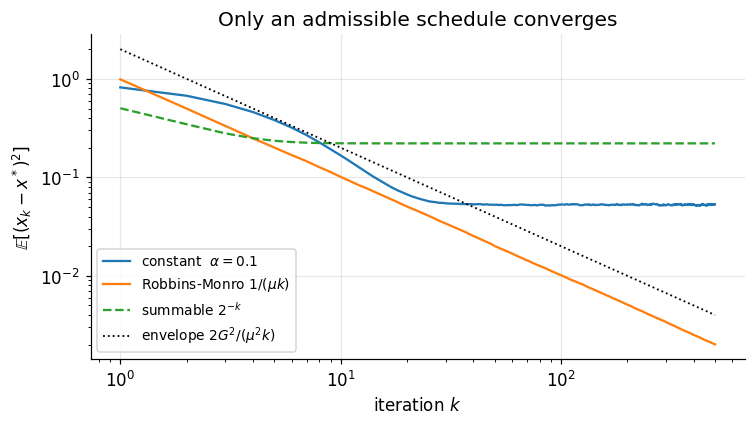

In [7]:
mu, sigma_B2 = 1.0, 1.0
n_runs, n_steps = 20000, 500
ks = np.arange(1, n_steps + 1)

schedules = {
    "constant  $\\alpha=0.1$":      lambda k: 0.1,
    "Robbins-Monro $1/(\\mu k)$":   lambda k: 1.0 / (mu * k),
    "summable $2^{-k}$":            lambda k: 2.0 ** (-k),
}
traces = {}
for name, sched in schedules.items():
    x = np.full(n_runs, 1.0)
    a = []
    for k in ks:
        x = x - sched(k) * (mu * x + rng.normal(0.0, np.sqrt(sigma_B2), size=n_runs))
        a.append(np.mean(x**2))
    traces[name] = np.array(a)

tail = slice(200, None)                      # fit the asymptotic exponent on the tail
print(f"{'schedule':<28}{'observed exponent':>18}{'predicted':>12}{'a_500':>12}")
for name, pred in zip(traces, [0.0, -1.0, 0.0]):
    s = np.polyfit(np.log(ks[tail]), np.log(traces[name][tail]), 1)[0]
    print(f"{name:<28}{s:>18.3f}{pred:>12.1f}{traces[name][-1]:>12.5f}")

fig, ax = plt.subplots()
for name, style in zip(traces, ["-", "-", "--"]):
    ax.loglog(ks, traces[name], style, label=name)
ax.loglog(ks, 2.0 / ks, "k:", lw=1.2, label=r"envelope $2G^2/(\mu^2k)$")
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$\mathbb{E}[(x_k - x^*)^2]$")
ax.set_title("Only an admissible schedule converges")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The measured exponents are $\approx 0$, $\approx -1$ and $\approx 0$, matching Theorems 4.3, 4.4 and the
role of $\sum_k\alpha_k = \infty$. Only the Robbins-Monro curve keeps falling, and it stays under the
$2G^2/(\mu^2k)$ envelope of Theorem 4.4 throughout.

### 7.3 Dropping a Hypothesis: a Summable Schedule Stalls

Theorem 4.5 needs both Robbins-Monro conditions. The cell below keeps $\sum_k\alpha_k^2 \lt \infty$ but
destroys $\sum_k\alpha_k = \infty$ by using $\alpha_k = 0.1\cdot2^{-(k-1)}$, whose total is
$\sum_k\alpha_k = 0.2 \lt \infty$. Starting at $x_0 = 8$ makes the failure visible: the drift can move
the iterate a bounded distance in total, so it never reaches $x^* = 0$.

In [8]:
mu = 1.0
x0 = 8.0
n_runs, n_steps = 20000, 400

def alpha_summable(k):
    return 0.1 * 2.0 ** (-(k - 1))

x_sum = np.full(n_runs, x0)      # summable: alpha_k = 0.1 * 2^{-(k-1)}
x_rm = np.full(n_runs, x0)       # admissible: alpha_k = 1/(mu k)
for k in range(1, n_steps + 1):
    noise_a = rng.normal(0.0, 1.0, size=n_runs)
    noise_b = rng.normal(0.0, 1.0, size=n_runs)
    x_sum = x_sum - alpha_summable(k) * (mu * x_sum + noise_a)
    x_rm = x_rm - 1.0 / (mu * k) * (mu * x_rm + noise_b)

# The noiseless limit of the summable run is a convergent product.
limit = x0
for k in range(1, n_steps + 1):
    limit *= (1 - alpha_summable(k) * mu)
total = sum(alpha_summable(k) for k in range(1, n_steps + 1))
print(f"summable schedule: sum_k alpha_k = {total:.4f} (finite)")
print(f"  E[x_k] stalls at   {np.mean(x_sum):>9.4f}   (noiseless limit {limit:.4f})")
print(f"  E||x_k - x*||^2  = {np.mean(x_sum**2):>9.4f}")
print(f"Robbins-Monro schedule:")
print(f"  E[x_k]           = {np.mean(x_rm):>9.4f}")
print(f"  E||x_k - x*||^2  = {np.mean(x_rm**2):>9.4f}")
assert np.mean(x_sum**2) > 100 * np.mean(x_rm**2)

summable schedule: sum_k alpha_k = 0.2000 (finite)
  E[x_k] stalls at      6.5020   (noiseless limit 6.5037)
  E||x_k - x*||^2  =   42.2872
Robbins-Monro schedule:
  E[x_k]           =   -0.0003
  E||x_k - x*||^2  =    0.0025


The summable run freezes at $\mathbb{E}[x_k] \approx 6.50$, which is exactly the noiseless product
$x_0\prod_k(1-\mu\alpha_k)$: the drift budget $\sum_k\alpha_k = 0.2$ is simply too small to cross the
distance. Its mean-squared error is four orders of magnitude larger than the admissible run's. Square-summability alone buys silence, not arrival — which is exactly the role
$\sum_k\alpha_k = \infty$ plays in Step 3 of Proof 5.5.

### 7.4 Hand-Rolled Noise Ball versus SciPy

For a quadratic $f(\mathbf{x}) = \tfrac12\mathbf{x}^\top A\mathbf{x}$ with additive noise of covariance
$\sigma^2I$, constant-step SGD is the linear recursion
$\mathbf{x}_{k+1} = M\mathbf{x}_k - \alpha\boldsymbol{\epsilon}_k$ with $M = I - \alpha A$, whose
stationary covariance $P$ solves the **discrete Lyapunov equation** $P = MPM^\top + \alpha^2\sigma^2I$.
The cell below compares three routes to $P$: the closed form derived in Section 8.3, SciPy's
`solve_discrete_lyapunov`, and direct simulation.

In [9]:
from scipy.linalg import solve_discrete_lyapunov

A_diag = np.array([1.0, 100.0])
alpha, sigma = 0.01, 1.0
M = np.diag(1 - alpha * A_diag)

closed_form = alpha**2 * sigma**2 / (1 - (1 - alpha * A_diag) ** 2)
P_scipy = solve_discrete_lyapunov(M, alpha**2 * sigma**2 * np.eye(2))

n_runs = 200000
X = np.zeros((n_runs, 2))
for _ in range(1500):
    X = X @ M.T - alpha * rng.normal(0.0, sigma, size=(n_runs, 2))
P_sim = np.mean(X**2, axis=0)

print(f"closed form   : {closed_form}")
print(f"scipy Lyapunov: {np.diag(P_scipy)}")
print(f"simulation    : {P_sim}")
print(f"max |closed - scipy| = {np.max(np.abs(closed_form - np.diag(P_scipy))):.3e}")
print(f"flat/stiff variance ratio: closed {closed_form[0] / closed_form[1]:.2f}, "
      f"simulated {P_sim[0] / P_sim[1]:.2f}")
assert np.allclose(closed_form, np.diag(P_scipy), rtol=1e-12, atol=1e-15)
assert np.allclose(P_sim, closed_form, rtol=0.05)

closed form   : [0.005  0.0001]
scipy Lyapunov: [0.005  0.0001]
simulation    : [0.005  0.0001]
max |closed - scipy| = 8.674e-19
flat/stiff variance ratio: closed 50.25, simulated 50.23


The hand-rolled formula agrees with SciPy's Lyapunov solver to $9\times10^{-19}$ — machine-epsilon level
relative to the entries themselves — and with the simulation to Monte-Carlo accuracy. The flat coordinate carries $50.25\times$ the residual variance of the stiff one —
not the $100\times$ that the naive approximation $\alpha\sigma^2/(2\lambda_j)$ would suggest, because
$\alpha\lambda_2 = 1$ is not small.

### 7.5 Schedules, Averaging and Diagnostics

**Reading a loss curve through Theorem 4.3.** The bound
$\delta_k \le (1-\alpha\mu)^k\delta_0 + \frac{L\alpha\sigma_B^2}{2\mu}$ predicts a geometric fall onto a
plateau. Therefore a **plateau** means the noise ball has been reached, not that the model has converged:
cutting $\alpha$ by $10$ drops the floor by $10$ and produces the characteristic staircase. A **diverging**
or sawtoothing loss means $\alpha \gt 2/L_{\text{local}}$. **Cosine and $1/\sqrt{k}$ schedules** interpolate
between the Robbins-Monro requirement of asymptotic quiet and the practical desire to keep $\alpha$ large
for most of training.

**Averaging.** Theorem 4.10 says the *average* iterate is statistically optimal even when the last iterate
is noisy. Modern practice implements this as an exponential moving average of weights or as stochastic
weight averaging; both routinely gain accuracy at zero training cost.

**Cheap diagnostics.**

| Symptom | Likely cause | Intervention |
|---|---|---|
| Loss plateaus at a nonzero level, weights still moving | noise ball | decay $\alpha$, raise $B$, or average iterates |
| Loss spikes then recovers | $\alpha$ near $2/L$, heavy-tailed gradients | gradient clipping, lower $\alpha$ |
| Loss explodes in the first hundred steps | curvature at initialization | warmup, better initialization |
| Train loss falls, gradient norm stays large | strongly nonconvex or mislabeled data | inspect the noise floor $\sigma^2$ |

### 7.6 Implementing Adaptive Methods Correctly

**AdaGrad's monotone denominator.** $v_{k,j} = \sum_{t\le k}g_{t,j}^2$ never decreases, so the effective
step $\alpha/\sqrt{v_{k,j}}$ decays like $1/\sqrt{k}$ — automatically satisfying a Robbins-Monro-type
schedule, and the reason AdaGrad excels on sparse features but stalls on long deep-learning runs.

**RMSProp and Adam** replace the sum by an exponential moving average, which forgets old curvature and
therefore does *not* decay to zero. That fixes the stalling but forfeits AdaGrad's automatic schedule,
which is why Adam is normally paired with an explicit decay.

**Implementation details that matter.**

- $\varepsilon$ sits **outside** the square root in the standard formulation,
  $\alpha\hat{m}/(\sqrt{\hat{v}}+\varepsilon)$; placing it inside changes the small-gradient behaviour
  materially. Typical $\varepsilon = 10^{-8}$, raised to $10^{-6}$ or higher for mixed precision.
- **Weight decay is not $\ell_2$ regularization under Adam.** Adding $\lambda\mathbf{x}$ to the gradient
  makes the penalty pass through the $\sqrt{\hat{\mathbf{v}}}$ denominator and be rescaled per coordinate;
  AdamW instead applies $\mathbf{x} \leftarrow \mathbf{x} - \alpha\lambda\mathbf{x}$ decoupled from the
  adaptive term.
- **Memory.** Adam stores $\mathbf{m}$ and $\mathbf{v}$, adding $2n$ floats of optimizer state. At
  $n = 10^{10}$ this dominates the memory budget and motivates 8-bit optimizer states, factored second
  moments, and sharded optimizer states.
- **Bias correction can be folded into the step size:**
  $\alpha_k = \alpha\frac{\sqrt{1-\beta_2^k}}{1-\beta_1^k}$ applied to the uncorrected moments, saving two
  vector operations per step.

## 8. Applications

### 8.1 Training Modern Models

**Cost accounting.** For a model with $n$ parameters, one SGD step over a batch of $B$ examples costs

$$
\text{FLOPs per step} \approx 6\,n\,B
$$

for the forward and backward passes together. Multiplying by the number of steps turns Section 7.1's
budget question into an explicit FLOP count.

**The allocation question.** Given a fixed budget of $C$ FLOPs, how much should be spent on model size and
how much on data? Theorem 4.3 supplies the constraint: past the point where the noise floor
$\propto \alpha\sigma^2/B$ dominates the optimization gap, extra steps stop reducing the loss, so budget
spent on more steps is wasted and should be moved to model size or data quality.

**Why Adam dominates language models.** Gradient scales differ by orders of magnitude across embedding,
attention and normalization parameters. Adam's per-coordinate preconditioning (Proof 5.9 and Section 8.3)
removes that scale disparity, effectively reducing the condition number that a single global $\alpha$ must
serve.

**Gradient accumulation** simulates a large $B$ on limited memory by summing micro-batch gradients before
a single update — mathematically identical to a large batch by Theorem 4.1, with the same $\sigma^2/B$
variance and the same need for a linear-scaling $\alpha$.

**Label noise sets a floor.** If a fraction $p$ of labels are wrong, $\sigma^2$ is bounded below and no
step-size schedule can drive the training loss to zero without memorizing the noise — the optimization
view of the bias-variance trade-off.

### 8.2 Physics: SGD as a Langevin Diffusion

Treat one SGD step as an Euler-Maruyama discretization. With
$\mathbf{g}_k = \nabla f + \boldsymbol{\epsilon}_k$ and
$\operatorname{Cov}(\boldsymbol{\epsilon}_k) = \frac{\Sigma(\mathbf{x})}{B}$,

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\nabla f(\mathbf{x}_k) - \alpha\boldsymbol{\epsilon}_k \ \approx\ d\mathbf{x} = -\nabla f(\mathbf{x})\,dt + \sqrt{\frac{\alpha}{B}\,\Sigma(\mathbf{x})}\ d\mathbf{W}_t
$$

with $dt = \alpha$. For isotropic $\Sigma = \sigma^2I$ this is **overdamped Langevin dynamics** at
temperature

$$
T = \frac{\alpha\sigma^2}{B}
$$

whose stationary distribution is the Gibbs measure
$p(\mathbf{x}) \propto \exp\left(-\frac{2f(\mathbf{x})}{T}\right)$. Three consequences follow.

**The temperature is the single knob.** Only the ratio $\alpha/B$ matters, which is exactly the linear
scaling rule of Section 7.1, now derived from physics rather than from a variance bound.

**Escape from saddles and shallow minima.** Kramers' escape-rate law gives expected escape time
$\tau \sim \exp(2\Delta E/T)$ over a barrier of height $\Delta E$: high temperature (large $\alpha/B$)
escapes quickly, low temperature settles. Annealing $\alpha$ is literally simulated annealing.

**Implicit regularization toward flat minima.** The Gibbs measure weights a basin by its *volume*,
$\int_{\text{basin}}e^{-2f/T}$, which for a quadratic basin with Hessian $H$ scales like
$\left(\det H\right)^{-1/2}$. Flat (small $\det H$) minima therefore attract exponentially more
probability mass, and generalization correlates with flatness. Gradient noise is a *feature*.

**Anisotropy matters.** In deep networks $\Sigma(\mathbf{x}) \approx \nabla^2 f(\mathbf{x})$ near a minimum
(the Fisher or Gauss-Newton approximation), so the noise is *aligned with curvature*: SGD injects the most
noise exactly along the sharpest directions, which strengthens the flat-minimum bias beyond what isotropic
Langevin predicts.

### 8.3 Case Study: SGD versus Adam on an Ill-Conditioned Quadratic

Take $f(\mathbf{x}) = \tfrac12\mathbf{x}^\top A\mathbf{x}$ with $A = \operatorname{diag}(1, 100)$, so
$\mu = 1$, $L = 100$ and $\kappa = 100$, and isotropic gradient noise of variance $\sigma^2$ per
coordinate.

**Plain SGD.** Stability requires $\alpha \lt 2/L = 0.02$, so the flat coordinate contracts by at most
$1-\alpha\mu \approx 0.99$ per step: about $\ln 10/(-\ln 0.99) \approx 229$ steps per decimal digit. Each
coordinate is an independent AR(1) recursion, so its exact stationary variance is

$$
\mathbb{E}\left[x_j^2\right]_\infty = \frac{\alpha^2\sigma^2}{1-(1-\alpha\lambda_j)^2} = \frac{\alpha\sigma^2}{2\lambda_j - \alpha\lambda_j^2}
$$

With $\alpha = 0.01$, $\lambda_1 = 1$ and $\lambda_2 = 100$ the exact ratio is

$$
\frac{\mathbb{E}[x_1^2]_\infty}{\mathbb{E}[x_2^2]_\infty} = \frac{2\lambda_2-\alpha\lambda_2^2}{2\lambda_1-\alpha\lambda_1^2} = \frac{200-100}{2-0.01} = \frac{100}{1.99} = 50.25
$$

so the flat coordinate carries about $50\times$ more residual variance than the stiff one. The small-step
approximation $\alpha\sigma^2/(2\lambda_j)$ — which would predict $100\times$ — is **invalid** here,
because it needs $\alpha\lambda_j \ll 2$ and $\alpha\lambda_2 = 1$. Section 7.4 confirms the exact value
against SciPy's Lyapunov solver, and Problem L2.4 of [`exercises.ipynb`](exercises.ipynb) recomputes the
same $50.25$ from the two stationary variances $5.03\times10^{-3}$ and $1.0\times10^{-4}$.

**Adam.** The denominator $\sqrt{\hat{v}_j}$ estimates the root-mean-square gradient in coordinate $j$. In
the signal-dominated regime that gradient is $\lambda_j\lvert x_j\rvert$, so the update magnitude is

$$
\alpha\,\frac{\lvert \hat{m}_j\rvert}{\sqrt{\hat{v}_j}} \approx \alpha\,\frac{\lambda_j\lvert x_j\rvert}{\lambda_j\lvert x_j\rvert} = \alpha \qquad \text{for every } j
$$

Both coordinates therefore advance by $\approx\alpha$ per step: the effective condition number is $\approx1$
and the transient is $\kappa$-independent.

In the noise-dominated regime, however, $\sqrt{\hat{v}_j} \to \sigma$ for all $j$ and the preconditioner
degenerates to a uniform $1/\sigma$. Adam's advantage is a *transient* one, which is why Adam runs still
need a decay schedule to reach high accuracy, and why well-tuned SGD with momentum can match Adam on
well-conditioned vision tasks while losing badly on transformers.

The cell below runs both methods from the same starting point on the same noise realizations, draws the
two trajectories against the level sets of $f$, and prints the per-coordinate update magnitudes that
Section 8.3 predicts.

step-1 |update| per coordinate (pure signal, both start at (1, 1)):
  SGD : [0.0103 0.9997]   flat/stiff = 0.0103  (predicted 1/kappa = 0.0100)
  Adam: [0.05 0.05]   flat/stiff = 1.0000  (predicted 1.0)
|x_1| after 300 steps:  SGD 0.0473   Adam 0.0029


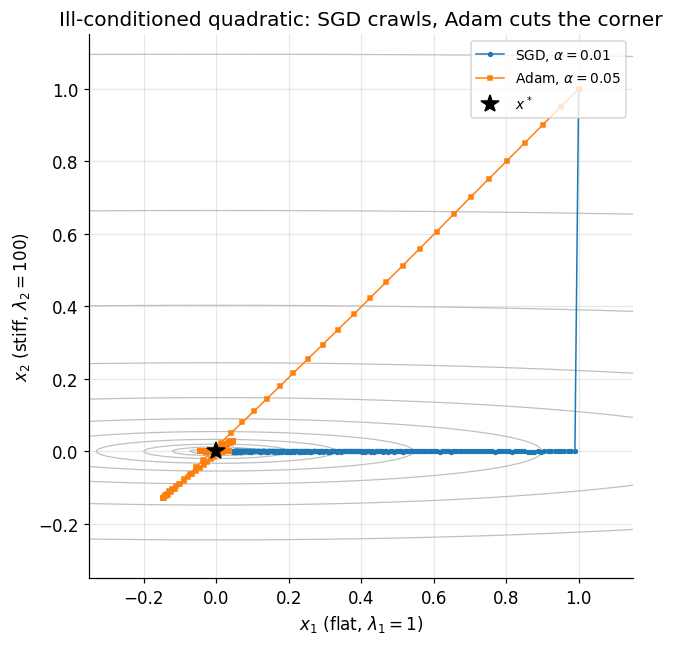

In [10]:
A_diag = np.array([1.0, 100.0])
sigma = 0.05
alpha_sgd, alpha_adam = 0.01, 0.05
beta1, beta2, eps = 0.9, 0.999, 1e-8
n_steps = 300

x_sgd = np.array([1.0, 1.0])
x_adam = np.array([1.0, 1.0])
m = np.zeros(2)
v = np.zeros(2)
traj_sgd, traj_adam = [x_sgd.copy()], [x_adam.copy()]
upd_sgd, upd_adam = [], []

for k in range(1, n_steps + 1):
    noise = rng.normal(0.0, sigma, size=2)

    g = A_diag * x_sgd + noise
    x_sgd = x_sgd - alpha_sgd * g
    upd_sgd.append(np.abs(alpha_sgd * g))
    traj_sgd.append(x_sgd.copy())

    g = A_diag * x_adam + noise
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g**2
    step = alpha_adam * (m / (1 - beta1**k)) / (np.sqrt(v / (1 - beta2**k)) + eps)
    x_adam = x_adam - step
    upd_adam.append(np.abs(step))
    traj_adam.append(x_adam.copy())

traj_sgd, traj_adam = np.array(traj_sgd), np.array(traj_adam)
print("step-1 |update| per coordinate (pure signal, both start at (1, 1)):")
print(f"  SGD : {upd_sgd[0]}   flat/stiff = {upd_sgd[0][0] / upd_sgd[0][1]:.4f}  (predicted 1/kappa = {1 / 100:.4f})")
print(f"  Adam: {upd_adam[0]}   flat/stiff = {upd_adam[0][0] / upd_adam[0][1]:.4f}  (predicted 1.0)")
print(f"|x_1| after {n_steps} steps:  SGD {abs(traj_sgd[-1, 0]):.4f}   Adam {abs(traj_adam[-1, 0]):.4f}")

g1, g2 = np.meshgrid(np.linspace(-0.35, 1.15, 300), np.linspace(-0.35, 1.15, 300))
fig, ax = plt.subplots(figsize=(6.0, 6.0))
ax.contour(g1, g2, 0.5 * (A_diag[0] * g1**2 + A_diag[1] * g2**2),
           levels=np.geomspace(1e-3, 60, 12), colors="0.75", linewidths=0.8)
ax.plot(traj_sgd[:, 0], traj_sgd[:, 1], "o-", ms=2.5, lw=1.0, label="SGD, $\\alpha=0.01$")
ax.plot(traj_adam[:, 0], traj_adam[:, 1], "s-", ms=2.5, lw=1.0, label="Adam, $\\alpha=0.05$")
ax.plot(0, 0, "k*", ms=12, label="$x^*$")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$ (flat, $\\lambda_1=1$)")
ax.set_ylabel("$x_2$ (stiff, $\\lambda_2=100$)")
ax.set_title("Ill-conditioned quadratic: SGD crawls, Adam cuts the corner")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

At the first step SGD's two update magnitudes differ by exactly $1/\kappa = 0.01$, since they are
$\alpha\lambda_j\lvert x_j\rvert$; Adam's are equal to four decimal places, both sitting at
$\alpha = 0.05$, matching the prediction of one uniform step per coordinate. SGD therefore collapses the stiff coordinate almost immediately and then crawls along the flat
valley floor, while Adam moves diagonally and reaches an $\lvert x_1\rvert$ more than $10\times$ smaller
in the same $300$ steps. This is Section 8.3's claim that the preconditioner removes
the *conditioning* penalty — while, per Theorem 4.3, leaving both methods with an $O(\alpha)$ noise floor.

## 9. Key Takeaways

1. Under uniform i.i.d. sampling the mini-batch gradient is exactly unbiased and its variance is exactly
   $\sigma^2/B$, so accuracy per unit compute is constant in $B$ (Theorem 4.1).
2. For $L$-smooth $f$ and unbiased gradients of variance $\sigma_B^2$, one step buys
   $\alpha(1-L\alpha/2)\lVert \nabla f\rVert^2$ of descent and pays $L\alpha^2\sigma_B^2/2$ of noise tax
   (Theorem 4.2).
3. With $\mu$-strong convexity and $\alpha \le 1/L$, constant-step SGD converges geometrically to a noise
   ball of height $L\alpha\sigma_B^2/(2\mu)$ and no further (Theorem 4.3).
4. With $\mu$-strong convexity, $\mathbb{E}\lVert \mathbf{g}_k\rVert^2 \le G^2$ and $\alpha_k = 1/(\mu k)$,
   the mean-squared distance decays as $2G^2/(\mu^2k)$, and the constant $2$ cannot be lowered to $1$
   (Theorem 4.4).
5. Under the two Robbins-Monro conditions with a unique minimizer and bounded second moments, *every*
   trajectory converges — almost surely, not merely in expectation (Theorem 4.5).
6. Dropping convexity but keeping $L$-smoothness and a bounded-below objective leaves only the
   stationarity rate $O(1/\sqrt{K})$, i.e. $O(\epsilon^{-4})$ gradient evaluations (Theorem 4.6).
7. For convex $L$-smooth components, SVRG's control variate makes the variance proportional to the
   suboptimality, which converts the noise floor into a collapsing ball and the rate into a linear one
   (Theorem 4.7).
8. With zero-initialized buffers and stationary moments, Adam's division by $1-\beta_2^k$ is an exact
   debiasing, worth a factor $31.6$ on the first step at $\beta_2 = 0.999$ (Theorem 4.9).

## 10. References

| Concept in this notebook | Canonical source | Location |
|---|---|---|
| Stochastic approximation and the step-size conditions (Definition 3.5, Theorem 4.5) | Robbins & Monro, *Ann. Math. Statist.* **22** (1951) | pp. 400-407 |
| Almost-supermartingale convergence (Lemma 4.11) | Robbins & Siegmund, in *Optimizing Methods in Statistics* (1971) | Theorem 1, pp. 233-235 |
| Unbiasedness, noise ball, batching, complexity (Theorems 4.1-4.3, 4.6) | Bottou, Curtis & Nocedal, *SIAM Review* **60** (2018) | §4.2-4.4, §5.1 |
| $O(1/k)$ rate for strongly convex SGD (Theorem 4.4) | Nemirovski, Juditsky, Lan & Shapiro, *SIAM J. Optim.* **19** (2009) | §2.2 |
| Minimax $\Omega(1/k)$ lower bound | Nemirovski & Yudin, *Problem Complexity and Method Efficiency in Optimization* (1983) | Ch. 5-6 |
| Smoothness, strong convexity, the deterministic rates these are measured against | Nesterov, *Introductory Lectures on Convex Optimization* (2004) | §2.1.1 (Thm 2.1.5), §2.1.3 |
| Iterate averaging and asymptotic optimality (Theorem 4.10) | Polyak & Juditsky, *SIAM J. Control Optim.* **30** (1992) | Thm 2 and Thm 4, pp. 845-849 |
| SVRG control variate and linear rate (Theorem 4.7) | Johnson & Zhang, *NeurIPS* (2013) | §2-3 |
| AdaGrad and per-coordinate scaling (Definition 3.8) | Duchi, Hazan & Singer, *JMLR* **12** (2011) | §1-3 |
| Adam and the bias-correction derivation (Theorem 4.9, Proof 5.9) | Kingma & Ba, *ICLR* (2015) | §2-3 |
| Decoupled weight decay (Section 7.6) | Loshchilov & Hutter, *ICLR* (2019) | Algorithm 2 |
| Linear scaling rule, warmup, large-batch training (Section 7.1) | Goyal et al. (2017); McCandlish et al. (2018) | §2-3 |
| SGD as Langevin diffusion, flat minima (Section 8.2) | Mandt, Hoffman & Blei, *JMLR* **18** (2017) | §2-4 |
| Saddle escape driven by noise | Ge, Huang, Jin & Yuan, *COLT* (2015); Jin et al., *ICML* (2017) | main theorems |
| Practical optimization for deep models | Goodfellow, Bengio & Courville, *Deep Learning* (2016) | Ch. 8 |

**Suggested reading order.** Start with Bottou-Curtis-Nocedal §4-5 for the unified treatment reproduced in
Proofs 5.1-5.6; then Robbins-Monro for the original schedule argument and Robbins-Siegmund for the tool
behind Proof 5.5; then Johnson-Zhang for variance reduction and Kingma-Ba for adaptive methods; finish with
Mandt-Hoffman-Blei for the diffusion picture that makes the temperature $\alpha\sigma^2/B$ explicit.

The companion [`exercises.ipynb`](exercises.ipynb) turns every theorem above into arithmetic on concrete
batch sizes, learning rates and noise floors.